구글 드라이브 연결

In [19]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Google Drive is mounted.")

Mounted at /content/drive
Google Drive is mounted.


라이브러리 설치 및 임포트

In [20]:
!pip install cartopy
!pip install pykrige

In [21]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from pykrige.ok import OrdinaryKriging
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

### 설정

In [22]:
# 경로 설정

# 도호쿠
TOHOKU_PRED_CSV_PATH   = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/tohoku_predicted_pgv_25km_360_180.csv"               # seismic_station, pgv_pred
TOHOKU_META_ALL_CSV_PATH   = "/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/tohoku/tohoku_station_pairs.csv"
TOHOKU_PRED_GRID_CSV = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/tohoku_pred_grid_25km_360_180_test.csv"
TOHOKU_KRIGING_GRID_CSV = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/tohoku_kriging_pred_25km_360_180_test.csv"

# 노토
NOTO_PRED_CSV_PATH   = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/noto_predicted_pgv_25km_360_180.csv"               # seismic_station, pgv_pred
NOTO_META_ALL_CSV_PATH   = "/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/noto/noto_station_pairs.csv"
NOTO_PRED_GRID_CSV = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/noto_pred_grid_25km_360_180_test.csv"
NOTO_KRIGING_GRID_CSV = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/noto_kriging_pred_25km_360_180_test.csv"

# 쿠마모토
KUMAMOTO_PRED_CSV_PATH   = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/kumamoto_predicted_pgv_25km_360_180.csv"               # seismic_station, pgv_pred
KUMAMOTO_META_ALL_CSV_PATH   = "/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/kumamoto/kumamoto_station_pairs.csv"
KUMAMOTO_PRED_GRID_CSV = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/kumamoto_pred_grid_25km_360_180_test.csv"
KUMAMOTO_KRIGING_GRID_CSV = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/kumamoto_kriging_pred_25km_360_180_test.csv"

# 홋카이도
HOKKAIDO_PRED_CSV_PATH   = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/hokkaido_predicted_pgv_25km_360_180.csv"               # seismic_station, pgv_pred
HOKKAIDO_META_ALL_CSV_PATH   = "/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/hokkaido/hokkaido_station_pairs.csv"
HOKKAIDO_PRED_GRID_CSV = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/hokkaido_pred_grid_25km_360_180_test.csv"
HOKKAIDO_KRIGING_GRID_CSV = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/hokkaido_kriging_pred_25km_360_180_test.csv"

OUTPUT_FIG_PATH = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/shakemap_25km_360_180_test.png"

# Kriging

### 크리깅 입력용 csv 생성

In [23]:
# ===== 1. 도호쿠 =====

AGG_FUNC = "mean"

# PRED_CSV_PATH 불러오기
pred_df = pd.read_csv(TOHOKU_PRED_CSV_PATH)
pred_df = pred_df[["seismic_station", "pgv_pred"]].copy()

pred_df["seismic_station"] = (
    pred_df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

pred_df["pgv_pred"] = pd.to_numeric(pred_df["pgv_pred"], errors="coerce")
pred_df = pred_df.dropna(subset=["seismic_station", "pgv_pred"])

print("예측 CSV 행 수:", len(pred_df))

# META_ALL_CSV_PATH 불러오기
meta_df = pd.read_csv(TOHOKU_META_ALL_CSV_PATH)
meta_df = meta_df[["seismic_station", "seismic_lat", "seismic_lon"]].copy()

meta_df["seismic_station"] = (
    meta_df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

meta_df["seismic_lat"] = pd.to_numeric(meta_df["seismic_lat"], errors="coerce")
meta_df["seismic_lon"] = pd.to_numeric(meta_df["seismic_lon"], errors="coerce")
meta_df = meta_df.dropna(subset=["seismic_station", "seismic_lat", "seismic_lon"])

print("메타 CSV 행 수:", len(meta_df))

# META_CSV_PATH 중복 제거
meta_unique = (
    meta_df.groupby("seismic_station", as_index=False)
    .agg({
        "seismic_lat": "first",
        "seismic_lon": "first"
    })
)

print("중복 제거 후 메타 관측소 수:", len(meta_unique))

# PRED_CSV_PATH 중복 처리
dup_count = pred_df["seismic_station"].duplicated().sum()
print("예측 CSV 중복 station 수:", dup_count)

if AGG_FUNC == "mean":
    pred_unique = pred_df.groupby("seismic_station", as_index=False).agg({"pgv_pred": "mean"})
elif AGG_FUNC == "first":
    pred_unique = pred_df.groupby("seismic_station", as_index=False).agg({"pgv_pred": "first"})
else:
    raise ValueError("AGG_FUNC must be one of: mean, first")

print("중복 처리 후 예측 관측소 수:", len(pred_unique))

# merge
merged_df = pd.merge(
    pred_unique,
    meta_unique,
    on="seismic_station",
    how="left"
)

print("merge 후 행 수:", len(merged_df))

# 좌표 매칭 실패 확인
missing_coord_df = merged_df[
    merged_df["seismic_lat"].isna() | merged_df["seismic_lon"].isna()
]

print("좌표 매칭 실패 관측소 수:", len(missing_coord_df))

if len(missing_coord_df) > 0:
    print("\n좌표 매칭 실패 예시:")
    print(missing_coord_df.head())

# 좌표 없는 행 제거
merged_df = merged_df.dropna(subset=["seismic_lat", "seismic_lon"]).copy()

# 컬럼 순서 정리
merged_df = merged_df[
    ["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"]
]

# 저장
merged_df.to_csv(TOHOKU_PRED_GRID_CSV, index=False)

print(f"\n크리깅 입력용 CSV 저장 완료: {TOHOKU_PRED_GRID_CSV}")
print(merged_df.head())

예측 CSV 행 수: 138
메타 CSV 행 수: 186
중복 제거 후 메타 관측소 수: 101
예측 CSV 중복 station 수: 49
중복 처리 후 예측 관측소 수: 89
merge 후 행 수: 89
좌표 매칭 실패 관측소 수: 0

크리깅 입력용 CSV 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/tohoku_pred_grid_25km_360_180_test.csv
  seismic_station  seismic_lat  seismic_lon  pgv_pred
0          N.AHIH      38.2799     139.5486     2.457
1          N.AJSH      40.7618     140.3121     1.096
2          N.ANIH      39.9819     140.4072     2.654
3          N.AOMH      40.8524     140.6759     1.366
4          N.ASAH      38.4704     139.7606     4.540


In [24]:
# ===== 2. 노토 =====

AGG_FUNC = "mean"

# PRED_CSV_PATH 불러오기
pred_df = pd.read_csv(NOTO_PRED_CSV_PATH)
pred_df = pred_df[["seismic_station", "pgv_pred"]].copy()

pred_df["seismic_station"] = (
    pred_df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

pred_df["pgv_pred"] = pd.to_numeric(pred_df["pgv_pred"], errors="coerce")
pred_df = pred_df.dropna(subset=["seismic_station", "pgv_pred"])

print("예측 CSV 행 수:", len(pred_df))

# META_CSV_PATH 불러오기
meta_df = pd.read_csv(NOTO_META_ALL_CSV_PATH)
meta_df = meta_df[["seismic_station", "seismic_lat", "seismic_lon"]].copy()

meta_df["seismic_station"] = (
    meta_df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

meta_df["seismic_lat"] = pd.to_numeric(meta_df["seismic_lat"], errors="coerce")
meta_df["seismic_lon"] = pd.to_numeric(meta_df["seismic_lon"], errors="coerce")
meta_df = meta_df.dropna(subset=["seismic_station", "seismic_lat", "seismic_lon"])

print("메타 CSV 행 수:", len(meta_df))

# META_CSV_PATH 중복 제거
meta_unique = (
    meta_df.groupby("seismic_station", as_index=False)
    .agg({
        "seismic_lat": "first",
        "seismic_lon": "first"
    })
)

print("중복 제거 후 메타 관측소 수:", len(meta_unique))

# PRED_CSV_PATH 중복 처리
dup_count = pred_df["seismic_station"].duplicated().sum()
print("예측 CSV 중복 station 수:", dup_count)

if AGG_FUNC == "mean":
    pred_unique = pred_df.groupby("seismic_station", as_index=False).agg({"pgv_pred": "mean"})
elif AGG_FUNC == "first":
    pred_unique = pred_df.groupby("seismic_station", as_index=False).agg({"pgv_pred": "first"})
else:
    raise ValueError("AGG_FUNC must be one of: mean, first")

print("중복 처리 후 예측 관측소 수:", len(pred_unique))

# merge
merged_df = pd.merge(
    pred_unique,
    meta_unique,
    on="seismic_station",
    how="left"
)

print("merge 후 행 수:", len(merged_df))

# 좌표 매칭 실패 확인
missing_coord_df = merged_df[
    merged_df["seismic_lat"].isna() | merged_df["seismic_lon"].isna()
]

print("좌표 매칭 실패 관측소 수:", len(missing_coord_df))

if len(missing_coord_df) > 0:
    print("\n좌표 매칭 실패 예시:")
    print(missing_coord_df.head())

# 좌표 없는 행 제거
merged_df = merged_df.dropna(subset=["seismic_lat", "seismic_lon"]).copy()

# 컬럼 순서 정리
merged_df = merged_df[
    ["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"]
]

# 저장
merged_df.to_csv(NOTO_PRED_GRID_CSV, index=False)

print(f"\n크리깅 입력용 CSV 저장 완료: {NOTO_PRED_GRID_CSV}")
print(merged_df.head())

예측 CSV 행 수: 141
메타 CSV 행 수: 211
중복 제거 후 메타 관측소 수: 85
예측 CSV 중복 station 수: 62
중복 처리 후 예측 관측소 수: 79
merge 후 행 수: 79
좌표 매칭 실패 관측소 수: 0

크리깅 입력용 CSV 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/noto_pred_grid_25km_360_180_test.csv
  seismic_station  seismic_lat  seismic_lon  pgv_pred
0          N.AGMH      35.7870     137.7173     0.977
1          N.ASHH      35.2194     137.4039     0.960
2          N.ASNH      36.0940     137.3438     2.291
3          N.ASSH      36.0216     137.3906     1.991
4          N.ATKH      37.7317     139.8821     1.327


In [25]:
# ===== 3. 쿠마모토 =====

AGG_FUNC = "mean"

# PRED_CSV_PATH 불러오기
pred_df = pd.read_csv(KUMAMOTO_PRED_CSV_PATH)
pred_df = pred_df[["seismic_station", "pgv_pred"]].copy()

pred_df["seismic_station"] = (
    pred_df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

pred_df["pgv_pred"] = pd.to_numeric(pred_df["pgv_pred"], errors="coerce")
pred_df = pred_df.dropna(subset=["seismic_station", "pgv_pred"])

print("예측 CSV 행 수:", len(pred_df))

# META_CSV_PATH 불러오기
meta_df = pd.read_csv(KUMAMOTO_META_ALL_CSV_PATH)
meta_df = meta_df[["seismic_station", "seismic_lat", "seismic_lon"]].copy()

meta_df["seismic_station"] = (
    meta_df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

meta_df["seismic_lat"] = pd.to_numeric(meta_df["seismic_lat"], errors="coerce")
meta_df["seismic_lon"] = pd.to_numeric(meta_df["seismic_lon"], errors="coerce")
meta_df = meta_df.dropna(subset=["seismic_station", "seismic_lat", "seismic_lon"])

print("메타 CSV 행 수:", len(meta_df))

# META_CSV_PATH 중복 제거
meta_unique = (
    meta_df.groupby("seismic_station", as_index=False)
    .agg({
        "seismic_lat": "first",
        "seismic_lon": "first"
    })
)

print("중복 제거 후 메타 관측소 수:", len(meta_unique))

# PRED_CSV_PATH 중복 처리
dup_count = pred_df["seismic_station"].duplicated().sum()
print("예측 CSV 중복 station 수:", dup_count)

if AGG_FUNC == "mean":
    pred_unique = pred_df.groupby("seismic_station", as_index=False).agg({"pgv_pred": "mean"})
elif AGG_FUNC == "first":
    pred_unique = pred_df.groupby("seismic_station", as_index=False).agg({"pgv_pred": "first"})
else:
    raise ValueError("AGG_FUNC must be one of: mean, first")

print("중복 처리 후 예측 관측소 수:", len(pred_unique))

# merge
merged_df = pd.merge(
    pred_unique,
    meta_unique,
    on="seismic_station",
    how="left"
)

print("merge 후 행 수:", len(merged_df))

# 좌표 매칭 실패 확인
missing_coord_df = merged_df[
    merged_df["seismic_lat"].isna() | merged_df["seismic_lon"].isna()
]

print("좌표 매칭 실패 관측소 수:", len(missing_coord_df))

if len(missing_coord_df) > 0:
    print("\n좌표 매칭 실패 예시:")
    print(missing_coord_df.head())

# 좌표 없는 행 제거
merged_df = merged_df.dropna(subset=["seismic_lat", "seismic_lon"]).copy()

# 컬럼 순서 정리
merged_df = merged_df[
    ["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"]
]

# 저장
merged_df.to_csv(KUMAMOTO_PRED_GRID_CSV, index=False)

print(f"\n크리깅 입력용 CSV 저장 완료: {KUMAMOTO_PRED_GRID_CSV}")
print(merged_df.head())

예측 CSV 행 수: 82
메타 CSV 행 수: 160
중복 제거 후 메타 관측소 수: 42
예측 CSV 중복 station 수: 44
중복 처리 후 예측 관측소 수: 38
merge 후 행 수: 38
좌표 매칭 실패 관측소 수: 0

크리깅 입력용 CSV 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/kumamoto_pred_grid_25km_360_180_test.csv
  seismic_station  seismic_lat  seismic_lon  pgv_pred
0          N.ASKH      32.2918     130.5777    6.0265
1          N.BZNH      33.5925     131.1348   14.7000
2          N.CRNH      31.3741     130.4333    1.1120
3          N.CZEH      33.5080     129.8877    2.5400
4          N.HKSH      32.8114     131.1010   21.7700


In [26]:
# ===== 4. 홋카이도 =====

AGG_FUNC = "mean"

# PRED_CSV_PATH 불러오기
pred_df = pd.read_csv(HOKKAIDO_PRED_CSV_PATH)
pred_df = pred_df[["seismic_station", "pgv_pred"]].copy()

pred_df["seismic_station"] = (
    pred_df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

pred_df["pgv_pred"] = pd.to_numeric(pred_df["pgv_pred"], errors="coerce")
pred_df = pred_df.dropna(subset=["seismic_station", "pgv_pred"])

print("예측 CSV 행 수:", len(pred_df))

# META_CSV_PATH 불러오기
meta_df = pd.read_csv(HOKKAIDO_META_ALL_CSV_PATH)
meta_df = meta_df[["seismic_station", "seismic_lat", "seismic_lon"]].copy()

meta_df["seismic_station"] = (
    meta_df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

meta_df["seismic_lat"] = pd.to_numeric(meta_df["seismic_lat"], errors="coerce")
meta_df["seismic_lon"] = pd.to_numeric(meta_df["seismic_lon"], errors="coerce")
meta_df = meta_df.dropna(subset=["seismic_station", "seismic_lat", "seismic_lon"])

print("메타 CSV 행 수:", len(meta_df))

# META_CSV_PATH 중복 제거
meta_unique = (
    meta_df.groupby("seismic_station", as_index=False)
    .agg({
        "seismic_lat": "first",
        "seismic_lon": "first"
    })
)

print("중복 제거 후 메타 관측소 수:", len(meta_unique))

# PRED_CSV_PATH 중복 처리
dup_count = pred_df["seismic_station"].duplicated().sum()
print("예측 CSV 중복 station 수:", dup_count)

if AGG_FUNC == "mean":
    pred_unique = pred_df.groupby("seismic_station", as_index=False).agg({"pgv_pred": "mean"})
elif AGG_FUNC == "first":
    pred_unique = pred_df.groupby("seismic_station", as_index=False).agg({"pgv_pred": "first"})
else:
    raise ValueError("AGG_FUNC must be one of: mean, first")

print("중복 처리 후 예측 관측소 수:", len(pred_unique))

# merge
merged_df = pd.merge(
    pred_unique,
    meta_unique,
    on="seismic_station",
    how="left"
)

print("merge 후 행 수:", len(merged_df))

# 좌표 매칭 실패 확인
missing_coord_df = merged_df[
    merged_df["seismic_lat"].isna() | merged_df["seismic_lon"].isna()
]

print("좌표 매칭 실패 관측소 수:", len(missing_coord_df))

if len(missing_coord_df) > 0:
    print("\n좌표 매칭 실패 예시:")
    print(missing_coord_df.head())

# 좌표 없는 행 제거
merged_df = merged_df.dropna(subset=["seismic_lat", "seismic_lon"]).copy()

# 컬럼 순서 정리
merged_df = merged_df[
    ["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"]
]

# 저장
merged_df.to_csv(HOKKAIDO_PRED_GRID_CSV, index=False)

print(f"\n크리깅 입력용 CSV 저장 완료: {HOKKAIDO_PRED_GRID_CSV}")
print(merged_df.head())

예측 CSV 행 수: 96
메타 CSV 행 수: 178
중복 제거 후 메타 관측소 수: 69
예측 CSV 중복 station 수: 36
중복 처리 후 예측 관측소 수: 60
merge 후 행 수: 60
좌표 매칭 실패 관측소 수: 0

크리깅 입력용 CSV 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/hokkaido_pred_grid_25km_360_180_test.csv
  seismic_station  seismic_lat  seismic_lon  pgv_pred
0          N.AGWH      43.0842     140.8199     4.420
1          N.ANNH      43.4361     144.0844     2.760
2          N.ASBH      41.9856     140.3087     3.105
3          N.AYWH      43.2708     143.4317     3.670
4          N.BEEH      43.5038     142.6006     2.723


### 크리깅

In [27]:
# ===== 1. 도호쿠 =====

GRID_RES = 0.02
MARGIN = 0.2
VARIOGRAM_MODEL = "spherical"

# 크리깅 입력용 CSV 불러오기
df = pd.read_csv(TOHOKU_PRED_GRID_CSV)

df = df[["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"]].copy()

df["seismic_station"] = (
    df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["seismic_lat"] = pd.to_numeric(df["seismic_lat"], errors="coerce")
df["seismic_lon"] = pd.to_numeric(df["seismic_lon"], errors="coerce")
df["pgv_pred"] = pd.to_numeric(df["pgv_pred"], errors="coerce")

df = df.dropna(subset=["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"])

print("크리깅 입력 행 수:", len(df))

# 크리깅 입력 준비
lons = df["seismic_lon"].values
lats = df["seismic_lat"].values
pgv_pred = df["pgv_pred"].values

# 0.02도 간격 grid 생성
grid_lon = np.arange(
    lons.min() - MARGIN,
    lons.max() + MARGIN + GRID_RES,
    GRID_RES
)

grid_lat = np.arange(
    lats.min() - MARGIN,
    lats.max() + MARGIN + GRID_RES,
    GRID_RES
)

print("grid_lon 개수:", len(grid_lon))
print("grid_lat 개수:", len(grid_lat))
print("격자 해상도:", GRID_RES, "도")

# Ordinary Kriging
OK = OrdinaryKriging(
    lons,
    lats,
    pgv_pred,
    variogram_model=VARIOGRAM_MODEL,
    coordinates_type="geographic",
    verbose=False,
    enable_plotting=False
)

z_pred, z_var = OK.execute("grid", grid_lon, grid_lat)

z_pred = np.asarray(z_pred)
z_var = np.asarray(z_var)

#결과 저장
lon_mesh, lat_mesh = np.meshgrid(grid_lon, grid_lat)

grid_df = pd.DataFrame({
    "lat": lat_mesh.ravel(),
    "lon": lon_mesh.ravel(),
    "pgv_kriged_pred": z_pred.ravel(),
    "kriging_var": z_var.ravel()
})

grid_df.to_csv(TOHOKU_KRIGING_GRID_CSV, index=False)
print(f"크리깅 결과 저장 완료: {TOHOKU_KRIGING_GRID_CSV}")

크리깅 입력 행 수: 89
grid_lon 개수: 168
grid_lat 개수: 274
격자 해상도: 0.02 도
크리깅 결과 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/tohoku_kriging_pred_25km_360_180_test.csv


In [28]:
# ===== 2. 노토 =====

GRID_RES = 0.02
MARGIN = 0.2
VARIOGRAM_MODEL = "spherical"

# 크리깅 입력용 CSV 불러오기
df = pd.read_csv(NOTO_PRED_GRID_CSV)

df = df[["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"]].copy()

df["seismic_station"] = (
    df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["seismic_lat"] = pd.to_numeric(df["seismic_lat"], errors="coerce")
df["seismic_lon"] = pd.to_numeric(df["seismic_lon"], errors="coerce")
df["pgv_pred"] = pd.to_numeric(df["pgv_pred"], errors="coerce")

df = df.dropna(subset=["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"])

print("크리깅 입력 행 수:", len(df))

# 크리깅 입력 준비
lons = df["seismic_lon"].values
lats = df["seismic_lat"].values
pgv_pred = df["pgv_pred"].values

# 0.02도 간격 grid 생성
grid_lon = np.arange(
    lons.min() - MARGIN,
    lons.max() + MARGIN + GRID_RES,
    GRID_RES
)

grid_lat = np.arange(
    lats.min() - MARGIN,
    lats.max() + MARGIN + GRID_RES,
    GRID_RES
)

print("grid_lon 개수:", len(grid_lon))
print("grid_lat 개수:", len(grid_lat))
print("격자 해상도:", GRID_RES, "도")

# Ordinary Kriging
OK = OrdinaryKriging(
    lons,
    lats,
    pgv_pred,
    variogram_model=VARIOGRAM_MODEL,
    verbose=False,
    enable_plotting=False
)

z_pred, z_var = OK.execute("grid", grid_lon, grid_lat)

z_pred = np.asarray(z_pred)
z_var = np.asarray(z_var)

#결과 저장
lon_mesh, lat_mesh = np.meshgrid(grid_lon, grid_lat)

grid_df = pd.DataFrame({
    "lat": lat_mesh.ravel(),
    "lon": lon_mesh.ravel(),
    "pgv_kriged_pred": z_pred.ravel(),
    "kriging_var": z_var.ravel()
})

grid_df.to_csv(NOTO_KRIGING_GRID_CSV, index=False)
print(f"크리깅 결과 저장 완료: {NOTO_KRIGING_GRID_CSV}")

크리깅 입력 행 수: 79
grid_lon 개수: 239
grid_lat 개수: 159
격자 해상도: 0.02 도
크리깅 결과 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/noto_kriging_pred_25km_360_180_test.csv


In [29]:
# ===== 3. 쿠마모토 =====

GRID_RES = 0.02
MARGIN = 0.2
VARIOGRAM_MODEL = "spherical"

# 크리깅 입력용 CSV 불러오기
df = pd.read_csv(KUMAMOTO_PRED_GRID_CSV)

df = df[["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"]].copy()

df["seismic_station"] = (
    df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["seismic_lat"] = pd.to_numeric(df["seismic_lat"], errors="coerce")
df["seismic_lon"] = pd.to_numeric(df["seismic_lon"], errors="coerce")
df["pgv_pred"] = pd.to_numeric(df["pgv_pred"], errors="coerce")

df = df.dropna(subset=["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"])

print("크리깅 입력 행 수:", len(df))

# 크리깅 입력 준비
lons = df["seismic_lon"].values
lats = df["seismic_lat"].values
pgv_pred = df["pgv_pred"].values

# 0.02도 간격 grid 생성
grid_lon = np.arange(
    lons.min() - MARGIN,
    lons.max() + MARGIN + GRID_RES,
    GRID_RES
)

grid_lat = np.arange(
    lats.min() - MARGIN,
    lats.max() + MARGIN + GRID_RES,
    GRID_RES
)

print("grid_lon 개수:", len(grid_lon))
print("grid_lat 개수:", len(grid_lat))
print("격자 해상도:", GRID_RES, "도")

# Ordinary Kriging
OK = OrdinaryKriging(
    lons,
    lats,
    pgv_pred,
    variogram_model=VARIOGRAM_MODEL,
    verbose=False,
    enable_plotting=False
)

z_pred, z_var = OK.execute("grid", grid_lon, grid_lat)

z_pred = np.asarray(z_pred)
z_var = np.asarray(z_var)

#결과 저장
lon_mesh, lat_mesh = np.meshgrid(grid_lon, grid_lat)

grid_df = pd.DataFrame({
    "lat": lat_mesh.ravel(),
    "lon": lon_mesh.ravel(),
    "pgv_kriged_pred": z_pred.ravel(),
    "kriging_var": z_var.ravel()
})

grid_df.to_csv(KUMAMOTO_KRIGING_GRID_CSV, index=False)
print(f"크리깅 결과 저장 완료: {KUMAMOTO_KRIGING_GRID_CSV}")

크리깅 입력 행 수: 38
grid_lon 개수: 143
grid_lat 개수: 141
격자 해상도: 0.02 도
크리깅 결과 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/kumamoto_kriging_pred_25km_360_180_test.csv


In [30]:
# ===== 4. 홋카이도 =====

GRID_RES = 0.02
MARGIN = 0.2
VARIOGRAM_MODEL = "spherical"

# 크리깅 입력용 CSV 불러오기
df = pd.read_csv(HOKKAIDO_PRED_GRID_CSV)

df = df[["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"]].copy()

df["seismic_station"] = (
    df["seismic_station"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["seismic_lat"] = pd.to_numeric(df["seismic_lat"], errors="coerce")
df["seismic_lon"] = pd.to_numeric(df["seismic_lon"], errors="coerce")
df["pgv_pred"] = pd.to_numeric(df["pgv_pred"], errors="coerce")

df = df.dropna(subset=["seismic_station", "seismic_lat", "seismic_lon", "pgv_pred"])

print("크리깅 입력 행 수:", len(df))

# 크리깅 입력 준비
lons = df["seismic_lon"].values
lats = df["seismic_lat"].values
pgv_pred = df["pgv_pred"].values

# 0.02도 간격 grid 생성
grid_lon = np.arange(
    lons.min() - MARGIN,
    lons.max() + MARGIN + GRID_RES,
    GRID_RES
)

grid_lat = np.arange(
    lats.min() - MARGIN,
    lats.max() + MARGIN + GRID_RES,
    GRID_RES
)

print("grid_lon 개수:", len(grid_lon))
print("grid_lat 개수:", len(grid_lat))
print("격자 해상도:", GRID_RES, "도")

# Ordinary Kriging
OK = OrdinaryKriging(
    lons,
    lats,
    pgv_pred,
    variogram_model=VARIOGRAM_MODEL,
    verbose=False,
    enable_plotting=False
)

z_pred, z_var = OK.execute("grid", grid_lon, grid_lat)

z_pred = np.asarray(z_pred)
z_var = np.asarray(z_var)

#결과 저장
lon_mesh, lat_mesh = np.meshgrid(grid_lon, grid_lat)

grid_df = pd.DataFrame({
    "lat": lat_mesh.ravel(),
    "lon": lon_mesh.ravel(),
    "pgv_kriged_pred": z_pred.ravel(),
    "kriging_var": z_var.ravel()
})

grid_df.to_csv(HOKKAIDO_KRIGING_GRID_CSV, index=False)
print(f"크리깅 결과 저장 완료: {HOKKAIDO_KRIGING_GRID_CSV}")

크리깅 입력 행 수: 60
grid_lon 개수: 263
grid_lat 개수: 212
격자 해상도: 0.02 도
크리깅 결과 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/hokkaido_kriging_pred_25km_360_180_test.csv


# ShakeMap 시각화

### USGS 기준 PGV 범례
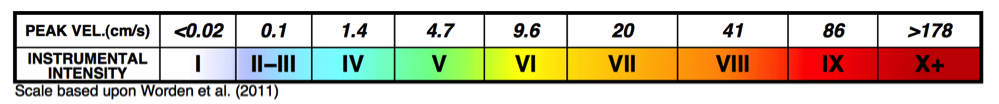

### 위험지도 생성

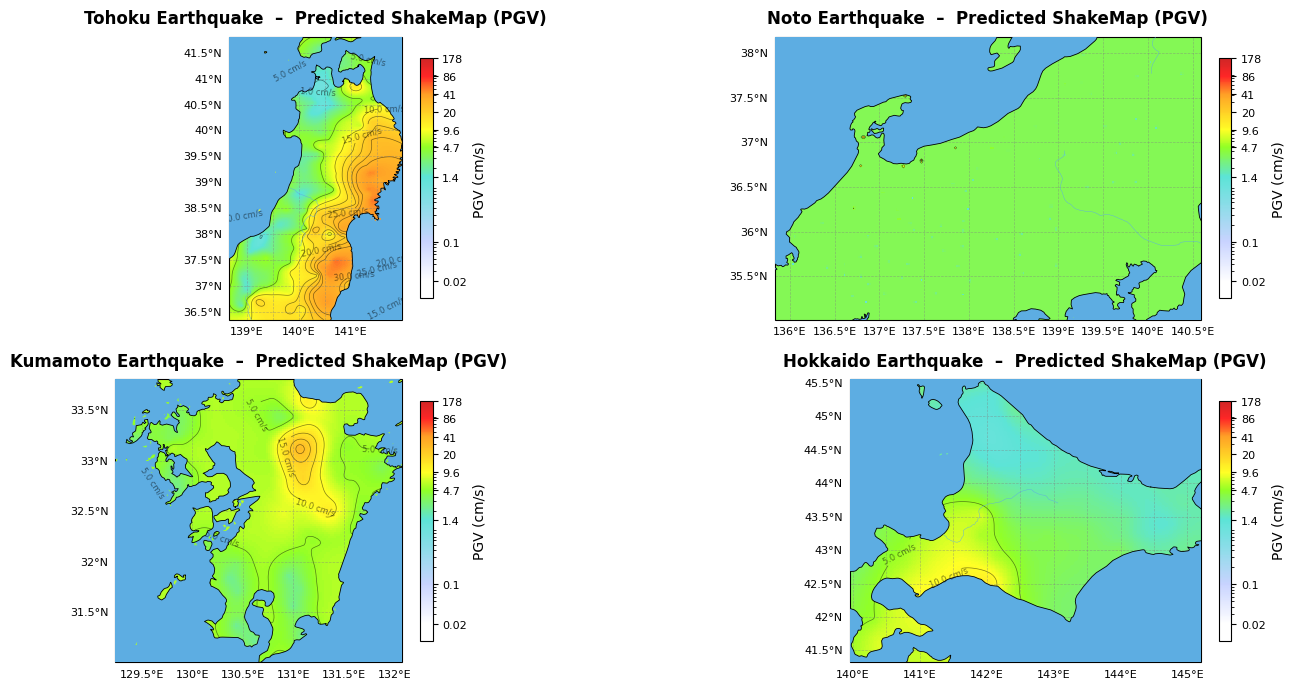

ShakeMap 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/추가 실험/shakemap_25km_360_180_test.png


In [31]:
PGV_MIN = 0.01
PGV_MAX = 178.0

DPI = 300

# USGS 기준 PGV 경계값 리스트
pgv_bounds = [0.0, 0.02, 0.1, 1.4, 4.7, 9.6, 20.0, 41.0, 86.0, 178.0, 300.0]

pgv_colors_list = [
    (0.01,  "#FFFFFF"),
    (0.02,  "#FFFFFF"),
    (0.10,  "#BFCCFF"),
    (1.40,  "#40E0D0"),
    (4.70,  "#7FFF00"),
    (9.60,  "#FFFF00"),
    (20.0,  "#FFC800"),
    (41.0,  "#FF9100"),
    (86.0,  "#FF0000"),
    (178.0, "#C80000"),
    (200.0, "#C80000")
]

log_min = np.log10(PGV_MIN)
log_max = np.log10(PGV_MAX)

color_list = []
for val, color in pgv_colors_list:
    pos = (np.log10(val) - log_min) / (log_max - log_min)
    pos = max(0.0, min(1.0, pos))
    color_list.append((pos, color))

pgv_cmap = mcolors.LinearSegmentedColormap.from_list("usgs_shakemap_gradient", color_list)
log_norm = mcolors.LogNorm(vmin=PGV_MIN, vmax=PGV_MAX)

def load_grid(csv_path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["lat", "lon", "pgv_kriged_pred"])
    df = df[df["pgv_kriged_pred"] > 0].copy()
    return df

def pivot_grid(df: pd.DataFrame):
    grid_lats = np.sort(df["lat"].unique())
    grid_lons = np.sort(df["lon"].unique())
    lon_2d, lat_2d = np.meshgrid(grid_lons, grid_lats)
    pgv_2d = (
        df.pivot_table(index="lat", columns="lon", values="pgv_kriged_pred")
        .reindex(index=grid_lats, columns=grid_lons)
        .values
    )
    var_2d = (
        df.pivot_table(index="lat", columns="lon", values="kriging_var")
        .reindex(index=grid_lats, columns=grid_lons)
        .values
    )
    return lon_2d, lat_2d, pgv_2d, var_2d

def add_map_features(ax):
    ax.add_feature(cfeature.LAND,      facecolor="white", zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor="#5DADE2", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black", zorder=4)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="gray", zorder=4, linestyle="--")
    ax.add_feature(cfeature.RIVERS,    linewidth=0.3, edgecolor="#5DADE2", zorder=4)

def add_gridlines(ax):
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xformatter   = LONGITUDE_FORMATTER
    gl.yformatter   = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}
    gl.xlocator = mticker.MultipleLocator(0.5)
    gl.ylocator = mticker.MultipleLocator(0.5)

def add_pgv_colorbar(fig, mesh, ax):
    cbar = fig.colorbar(
        mesh, ax=ax,
        orientation="vertical",
        fraction=0.03, pad=0.02, shrink=0.85,
    )
    cbar.set_label("PGV (cm/s)", fontsize=10)
    pgv_ticks = [0.02, 0.1, 1.4, 4.7, 9.6, 20.0, 41.0, 86.0, 178.0]
    cbar.set_ticks(pgv_ticks)
    cbar.set_ticklabels([f"{v:g}" for v in pgv_ticks], fontsize=8)

def plot_combined_shakemap(
    lon_2d_t, lat_2d_t, pgv_2d_t, extent_t,
    lon_2d_n, lat_2d_n, pgv_2d_n, extent_n,
    lon_2d_k, lat_2d_k, pgv_2d_k, extent_k,
    lon_2d_h, lat_2d_h, pgv_2d_h, extent_h,
    output_path
):
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        2, 2, # Changed from 2, 4 to 2, 2
        figsize=(18, 7),
        subplot_kw={"projection": proj},
        gridspec_kw={
            "width_ratios": [1, 1]
        }
    )

    titles = [
        "Tohoku Earthquake  –  Predicted ShakeMap (PGV)",
        "Noto Earthquake  –  Predicted ShakeMap (PGV)",
        "Kumamoto Earthquake  –  Predicted ShakeMap (PGV)",
        "Hokkaido Earthquake  –  Predicted ShakeMap (PGV)"
    ]
    data = [
        (lon_2d_t, lat_2d_t, pgv_2d_t, extent_t),
        (lon_2d_n, lat_2d_n, pgv_2d_n, extent_n),
        (lon_2d_k, lat_2d_k, pgv_2d_k, extent_k),
        (lon_2d_h, lat_2d_h, pgv_2d_h, extent_h)
    ]

    for ax, (lon_2d, lat_2d, pgv_2d, extent), title in zip(axes.flatten(), data, titles): # Added .flatten()
        ax.set_extent(extent, crs=proj)
        ax.set_aspect("equal", adjustable="box")
        add_map_features(ax)

        mesh = ax.pcolormesh(
            lon_2d, lat_2d, pgv_2d,
            cmap=pgv_cmap, norm=log_norm,
            transform=proj, alpha=0.85,
            zorder=1, shading="auto"
        )

        contour_levels = [0.1, 1.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
        cs = ax.contour(
            lon_2d, lat_2d, pgv_2d,
            levels=contour_levels,
            colors="black", linewidths=0.5,
            alpha=0.5, transform=proj, zorder=2
        )
        ax.clabel(cs, fmt="%.1f cm/s", fontsize=6, inline=True)
        add_pgv_colorbar(fig, mesh, ax)
        add_gridlines(ax)
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

    plt.tight_layout()
    fig.savefig(output_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"ShakeMap 저장 완료: {output_path}")

if __name__ == "__main__":
    df_t = load_grid(TOHOKU_KRIGING_GRID_CSV)
    lon_2d_t, lat_2d_t, pgv_2d_t, _ = pivot_grid(df_t)
    extent_t = [lon_2d_t.min(), lon_2d_t.max(), lat_2d_t.min(), lat_2d_t.max()]

    df_n = load_grid(NOTO_KRIGING_GRID_CSV)
    lon_2d_n, lat_2d_n, pgv_2d_n, _ = pivot_grid(df_n)
    extent_n = [lon_2d_n.min(), lon_2d_n.max(), lat_2d_n.min(), lat_2d_n.max()]

    df_k = load_grid(KUMAMOTO_KRIGING_GRID_CSV)
    lon_2d_k, lat_2d_k, pgv_2d_k, _ = pivot_grid(df_k)
    extent_k = [lon_2d_k.min(), lon_2d_k.max(), lat_2d_k.min(), lat_2d_k.max()]

    df_h = load_grid(HOKKAIDO_KRIGING_GRID_CSV)
    lon_2d_h, lat_2d_h, pgv_2d_h, _ = pivot_grid(df_h)
    extent_h = [lon_2d_h.min(), lon_2d_h.max(), lat_2d_h.min(), lat_2d_h.max()]

    plot_combined_shakemap(
        lon_2d_t, lat_2d_t, pgv_2d_t, extent_t,
        lon_2d_n, lat_2d_n, pgv_2d_n, extent_n,
        lon_2d_k, lat_2d_k, pgv_2d_k, extent_k,
        lon_2d_h, lat_2d_h, pgv_2d_h, extent_h,
        OUTPUT_FIG_PATH
    )